In [ ]:
! pip install torcheval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 7.2 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
from torch import tensor, nn
import torch.nn.functional as F
from torcheval.metrics import BinaryAccuracy

import sys
sys.path.append('/content')
from miniai.training import *
from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

## Load data

In [ ]:
import requests

In [ ]:
query_url = "https://rest.uniprot.org/uniprotkb/stream?compressed=true&fields=accession%2Csequence%2Ccc_subcellular_location&format=tsv&query=%28%28organism_id%3A9606%29+AND+%28reviewed%3Atrue%29+AND+%28length%3A%5B80+TO+500%5D%29%29"

In [ ]:
uniprot_req = requests.get(query_url)

In [ ]:
from io import BytesIO
import pandas as pd

uniprot_tab = BytesIO(uniprot_req.content)

df = pd.read_csv(uniprot_tab, compression='gzip', sep='\t')
df.head()

,Entry,Sequence,Subcellular location [CC]
0,A0A0K2S4Q6,MTQRAGAAMLPSALLLLCVPGCLTVSGPSTVMGAVGESLSVQCRYE...,SUBCELLULAR LOCATION: [Isoform 1]: Membrane {E...
1,A0AVI4,MDSPEVTFTLAYLVFAVCFVFTPNEFHAAGLTVQNLLSGWLGSEDA...,SUBCELLULAR LOCATION: Endoplasmic reticulum me...
2,A0JLT2,MENFTALFGAQADPPPPPTALGFGPGKPPPPPPPPAGGGPGTAPPP...,SUBCELLULAR LOCATION: Nucleus {ECO:0000305}.
3,A0M8Q6,GQPKAAPSVTLFPPSSEELQANKATLVCLVSDFNPGAVTVAWKADG...,SUBCELLULAR LOCATION: Secreted {ECO:0000303|Pu...
4,A0PJY2,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,SUBCELLULAR LOCATION: Nucleus {ECO:0000269|Pub...


In [ ]:
df = df.dropna()

In [ ]:
cytosol = df['Subcellular location [CC]'].str.contains('Cytosol') | df['Subcellular location [CC]'].str.contains('Cytoplasm')
membrane = df['Subcellular location [CC]'].str.contains('Membrane') | df['Subcellular location [CC]'].str.contains('Cell membrane')
nucleus = df['Subcellular location [CC]'].str.contains('Nucleus')

In [ ]:
cytosol_df = df[cytosol & ~membrane & ~nucleus]
len(cytosol_df)

1483

In [ ]:
memb_df = df[membrane & ~cytosol & ~nucleus]
len(memb_df)

2510

In [ ]:
nuc_df = df[nucleus & ~membrane & ~cytosol]
len(nuc_df)

1629

In [ ]:
cyt_seqs = cytosol_df['Sequence'].to_list()
cyt_labels = [0 for seq in cyt_seqs]

In [ ]:
memb_seqs = memb_df['Sequence'].to_list()
memb_labels = [1 for seq in memb_seqs]

In [ ]:
nuc_seqs = nuc_df['Sequence'].to_list()
nuc_labels = [2 for seq in nuc_seqs]

In [ ]:
seqs = cyt_seqs + memb_seqs + nuc_seqs
labels = cyt_labels + memb_labels + nuc_labels

In [ ]:
len(seqs) == len(labels)

True

## Tokenize sequences

In [ ]:
model_checkpoint = "facebook/esm2_t12_35M_UR50D"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, return_tensors='pt')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
tokenizer(seqs[0])

{'input_ids': [0, 20, 8, 8, 6, 17, 19, 16, 16, 8, 9, 5, 4, 8, 15, 14, 11, 18, 8, 9, 9, 16, 5, 8, 5, 4, 7, 9, 8, 7, 18, 6, 4, 15, 7, 8, 15, 7, 10, 14, 4, 14, 8, 19, 13, 13, 16, 17, 18, 21, 7, 19, 7, 8, 15, 11, 15, 13, 6, 14, 11, 9, 19, 7, 4, 15, 12, 8, 17, 11, 15, 5, 8, 15, 17, 14, 13, 4, 12, 9, 7, 16, 17, 21, 12, 12, 20, 18, 4, 15, 5, 5, 6, 18, 14, 11, 5, 8, 7, 23, 21, 11, 15, 6, 13, 17, 11, 5, 8, 4, 7, 8, 7, 13, 8, 6, 8, 9, 12, 15, 8, 19, 4, 7, 10, 4, 4, 11, 19, 4, 14, 6, 10, 14, 12, 5, 9, 4, 14, 7, 8, 14, 16, 4, 4, 19, 9, 12, 6, 15, 4, 5, 5, 15, 4, 13, 15, 11, 4, 16, 10, 18, 21, 21, 14, 15, 4, 8, 8, 4, 21, 10, 9, 17, 18, 12, 22, 17, 4, 15, 17, 7, 14, 4, 4, 9, 15, 19, 4, 19, 5, 4, 6, 16, 17, 10, 17, 10, 9, 12, 7, 9, 21, 7, 12, 21, 4, 18, 15, 9, 9, 7, 20, 11, 15, 4, 8, 21, 18, 10, 9, 23, 12, 17, 21, 6, 13, 4, 17, 13, 21, 17, 12, 4, 12, 9, 8, 8, 15, 8, 5, 8, 6, 17, 5, 9, 19, 16, 7, 8, 6, 12, 4, 13, 18, 6, 13, 20, 8, 19, 6, 19, 19, 7, 18, 9, 7, 5, 12, 11, 12, 20, 19, 20, 20, 12, 9, 8, 15

In [ ]:
model = AutoModel.from_pretrained(model_checkpoint).to(DEVICE)

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model

EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 480, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-11): 12 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=480, out_features=480, bias=True)
            (key): Linear(in_features=480, out_features=480, bias=True)
            (value): Linear(in_features=480, out_features=480, bias=True)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=480, out_features=480, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((480,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=480, out_features=1920, bias=True)
        )
        (output): EsmOutput(
      

In [ ]:
def embed_seqs(seq):
  tokens = tokenizer(seq, return_tensors='pt').to(DEVICE)
  with torch.no_grad():
    output = model(**tokens)
  return output.last_hidden_state[:,0,:].cpu().squeeze()

In [ ]:
from tqdm import tqdm

seq_emb = []

for seq in tqdm(seqs):
  seq_emb.append(embed_seqs(seq))

100%|██████████| 5622/5622 [01:41<00:00, 55.33it/s]


In [ ]:
len(seq_emb), seq_emb[0].shape

(5622, torch.Size([480]))

## Data splits

In [ ]:
from sklearn.model_selection import train_test_split

trainval_seqs, test_seqs, trainval_labels, test_labels = train_test_split(seq_emb, labels, test_size=0.2, shuffle=True)

In [ ]:
train_seqs, val_seqs, train_labels, val_labels = train_test_split(trainval_seqs, trainval_labels, test_size=0.1, shuffle=True)

In [ ]:
len(train_seqs), len(val_seqs), len(test_labels)

(4047, 450, 1125)

In [ ]:
train_labels.count(0), train_labels.count(1), train_labels.count(2)

(1064, 1811, 1172)

## Creating DataLoaders

In [ ]:
class ProteinDataset(Dataset):
    def __init__(self, x, y):
      super().__init__(x,y)

    def __getitem__(self, i):
        return self.x[i], tensor(self.y[i])

In [ ]:
train_ds = ProteinDataset(train_seqs, train_labels)
train_ds[0]

(tensor([-1.7800e-01, -2.8251e-01,  1.1171e-01,  2.2354e-01,  3.1175e-01,
         -7.0926e-02, -3.8407e-01, -2.0324e-02,  9.7203e-02,  9.1302e-02,
          2.2915e-01, -1.7524e-01,  8.1329e-02, -3.1760e-02,  3.7214e-01,
         -8.1176e-02,  1.9734e-01, -1.8092e-01, -1.1161e-02,  2.4503e-01,
          7.3296e-02,  1.6397e-02, -2.5328e-01,  4.2165e-01,  2.4585e-01,
         -5.8334e-02,  3.9227e-02, -2.0373e-02, -2.3988e-01, -1.7283e-01,
          5.9318e-02, -1.4730e-01, -4.1875e-01,  1.7446e-01,  8.0615e-02,
          2.0661e-01, -6.2079e-02,  4.4909e-01,  1.2179e-01, -1.8612e-01,
          1.5438e-01,  2.2792e-01,  9.1992e-02, -5.4343e-01, -3.9176e-02,
         -1.0217e-01,  5.3469e+00,  1.3946e-01, -2.1371e-01,  1.6434e-01,
         -1.4320e-01, -1.3254e-01, -2.7824e-01, -5.2650e-02,  4.0992e-01,
         -6.0299e-02, -2.0923e-01, -4.7266e-02, -1.7069e-01, -1.9659e-01,
         -4.0368e-01,  2.2574e-01,  1.4831e-01, -1.2557e-02, -1.7998e-01,
          2.5819e-01,  7.8846e-02,  6.

In [ ]:
valid_ds = ProteinDataset(val_seqs, val_labels)
valid_ds[0]

(tensor([-1.3252e-01, -2.0418e-01,  4.9879e-02,  2.1766e-01,  2.9302e-01,
          4.5879e-02, -4.7121e-01, -2.6624e-02,  1.5616e-01,  2.1274e-01,
          2.0906e-01, -2.1799e-01,  1.5000e-01, -5.3580e-02,  2.4253e-01,
         -6.5549e-02,  3.4344e-01, -1.8034e-01, -4.5958e-02,  4.2363e-01,
          3.0724e-03,  2.5670e-01, -2.3906e-01,  4.8233e-01,  2.9054e-01,
         -2.1064e-02,  1.3771e-01,  1.1460e-02, -2.8504e-01, -1.5356e-01,
          2.4046e-02, -2.4276e-01, -5.6261e-01,  2.8140e-01, -7.6707e-02,
          1.3693e-01, -6.0568e-02,  5.3780e-01,  3.1612e-01, -1.9464e-01,
          8.3250e-02,  2.7457e-02,  7.6776e-02, -5.7227e-01,  6.5900e-03,
          1.1257e-02,  5.0229e+00,  4.0830e-02, -2.3753e-01,  2.5554e-01,
         -2.9874e-01, -1.1834e-01, -3.1514e-01,  5.0567e-02,  3.5862e-01,
         -6.2472e-02, -1.4412e-01,  9.5905e-02, -1.4335e-01, -2.5728e-01,
         -5.4414e-01,  4.3585e-01,  2.3105e-01,  5.0754e-02, -8.8851e-02,
          1.5474e-01, -2.0450e-01,  5.

In [ ]:
from torch.utils.data import DataLoader

bs=256
dls = DataLoaders(*get_dls(train_ds, valid_ds, bs))

In [ ]:
next(iter(dls.train))[0].shape

torch.Size([256, 480])

## Create and train model

In [ ]:
mlp = nn.Sequential(
    nn.Linear(480, 256),
    nn.ReLU(),
    nn.LayerNorm(256),

    nn.Linear(256, 3)
)

In [ ]:
from torcheval.metrics import MulticlassAccuracy

epochs=10
lr=1e-2
cbs = [DeviceCB(), ProgressCB(plot=True), MetricsCB(accuracy=MulticlassAccuracy())]
learn = TrainLearner(mlp, dls, loss_func=F.cross_entropy, lr=lr, cbs=cbs, opt_func=torch.optim.Adam)

accuracy,loss,epoch,train
0.404,1.390,0,train
0.609,0.999,0,eval
0.581,0.882,1,train
0.667,0.771,1,eval
0.694,0.689,2,train
0.704,0.654,2,eval
0.728,0.610,3,train
0.722,0.601,3,eval
0.759,0.548,4,train
0.736,0.547,4,eval


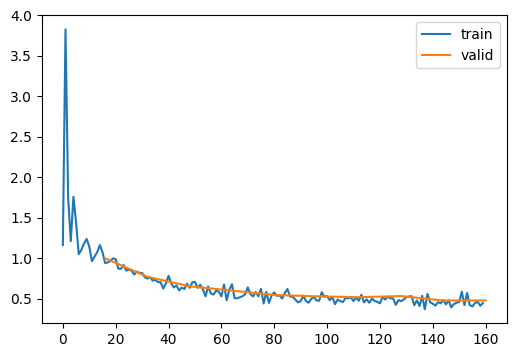

In [ ]:
learn.fit(epochs)

## Weight initialization

In [ ]:
def init_weights(m):
  if isinstance(m, nn.Linear):
    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    if m.bias is not None:
      nn.init.zeros_(m.bias)

In [ ]:
learn = TrainLearner(mlp.apply(init_weights), dls, loss_func=F.cross_entropy, lr=lr,
                     cbs=cbs, opt_func=torch.optim.Adam)

accuracy,loss,epoch,train
0.404,2.390,0,train
0.427,1.505,0,eval
0.485,1.062,1,train
0.591,0.920,1,eval
0.609,0.818,2,train
0.640,0.778,2,eval
0.670,0.727,3,train
0.658,0.725,3,eval
0.706,0.669,4,train
0.713,0.665,4,eval


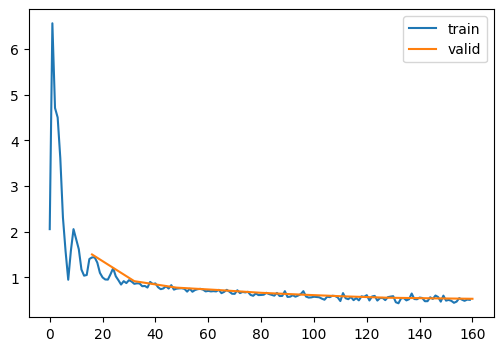

In [ ]:
learn.fit(epochs)

## Input normalization

In [ ]:
xb,yb = next(iter(dls.train))
xb

tensor([[-0.1410, -0.3080,  0.0629,  ..., -0.5424, -0.0414,  0.0368],
        [-0.2077, -0.3382, -0.0288,  ..., -0.5268,  0.0292, -0.0756],
        [-0.0732, -0.2592,  0.0547,  ..., -0.5837,  0.0668,  0.0511],
        ...,
        [-0.1097, -0.2271,  0.0673,  ..., -0.3371,  0.0272,  0.1064],
        [-0.3559, -0.2184,  0.0308,  ..., -0.5454, -0.0112, -0.0259],
        [-0.0088, -0.2052,  0.0645,  ..., -0.5403, -0.0184, -0.0558]])

In [ ]:
xmean, xstd = xb.mean(), xb.std()
xmean, xstd

(tensor(0.0061), tensor(0.3609))

In [ ]:
def _norm(b):
  return (b[0]-xmean)/xstd, b[1]

In [ ]:
norm = BatchTransformCB(_norm)

In [ ]:
learn = TrainLearner(mlp.apply(init_weights), dls, loss_func=F.cross_entropy, lr=lr, cbs=cbs+[norm], opt_func=torch.optim.Adam)

accuracy,loss,epoch,train
0.408,2.232,0,train
0.427,1.319,0,eval
0.516,0.947,1,train
0.607,0.846,1,eval
0.629,0.775,2,train
0.631,0.757,2,eval
0.698,0.694,3,train
0.700,0.687,3,eval
0.720,0.638,4,train
0.711,0.634,4,eval


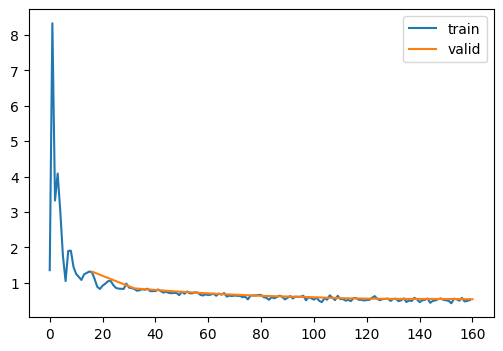

In [ ]:
learn.fit(epochs)

## LR Scheduler

In [ ]:
from torch.optim import lr_scheduler
from functools import partial

In [ ]:
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.CosineAnnealingLR, T_max=tmax)
lr_sched = BatchSchedCB(sched)

In [ ]:
learn = TrainLearner(mlp.apply(init_weights), dls, loss_func=F.cross_entropy, lr=lr, cbs=cbs+[norm, lr_sched], opt_func=torch.optim.Adam)

accuracy,loss,epoch,train
0.381,2.136,0,train
0.500,1.063,0,eval
0.523,0.963,1,train
0.529,0.873,1,eval
0.641,0.782,2,train
0.642,0.747,2,eval
0.688,0.700,3,train
0.676,0.699,3,eval
0.714,0.652,4,train
0.698,0.671,4,eval


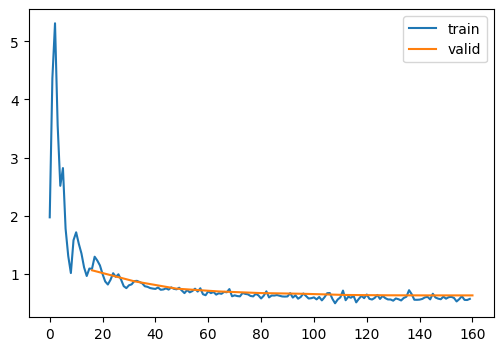

In [ ]:
learn.fit(epochs)

## Run final model on test set

In [ ]:
len(test_seqs), len(test_labels)

(1125, 1125)

In [ ]:
test_inp = torch.stack(test_seqs)
test_inp.shape

torch.Size([1125, 480])

In [ ]:
with torch.no_grad(): logits = learn.model(test_inp.to(DEVICE))

In [ ]:
preds = torch.argmax(logits, dim=1).cpu()

In [ ]:
y_test = tensor(test_labels)
acc = (preds == y_test).sum() / y_test.shape[0]
acc

tensor(0.7804)

## Evaluate model

In [ ]:
import numpy as np

conf_mat = np.zeros((3,3))

for i in range(3):
  idx = torch.argwhere(y_test == i)
  for j in range(3):
    conf_mat[i, j] += (preds[idx] == j).sum()

In [ ]:
conf_mat

array([[113.,  44., 128.],
       [ 17., 476.,  14.],
       [ 38.,   6., 289.]])

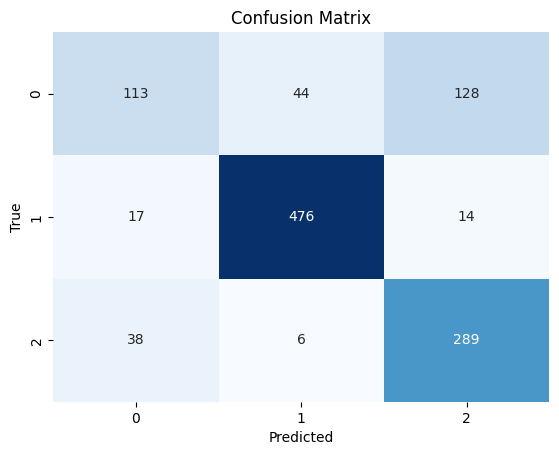

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_mat, annot=True, fmt='g', cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
per_class_acc = conf_mat.diagonal() / conf_mat.sum(axis=1)

for i, acc in enumerate(per_class_acc):
    print(f"Class {i} accuracy: {acc:.3f}")

Class 0 accuracy: 0.396
Class 1 accuracy: 0.939
Class 2 accuracy: 0.868


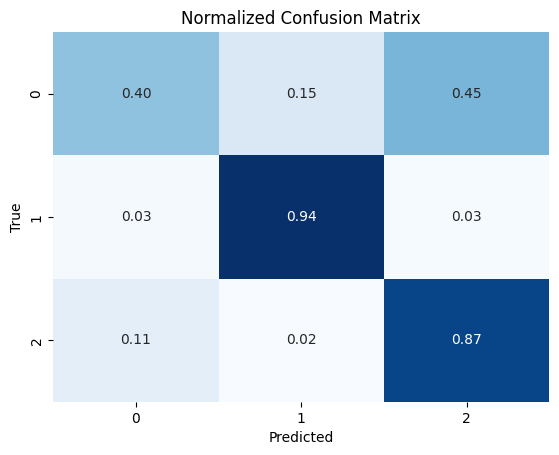

In [ ]:
cm_norm = conf_mat / conf_mat.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.67      0.40      0.50       285
           1       0.90      0.94      0.92       507
           2       0.67      0.87      0.76       333

    accuracy                           0.78      1125
   macro avg       0.75      0.73      0.73      1125
weighted avg       0.78      0.78      0.77      1125



Almost half the proteins with a truth label of cytosol (0) are getting misclassified as nuclear (2). Cytosol proteins have a low precision and recall. While nuclear proteins have a reasonably good recall, they have an equally low precision score i.e., of all the proteins the model classifies as nuclear, it is only correct ~67% of the time.

Thus, the model has a hard time differentiating between cytosolic and nuclear proteins. Particularly, it mistakes many of the cytosolic proteins for nuclear proteins.